# Model Evaluation
**Mục tiêu**: Đánh giá chi tiết model Random Forest + KMeans đã train.

- Load model từ `notebooks/model/artifacts/`
- Load data từ `data/processed/`


In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

print("Libraries loaded ✓")


Libraries loaded ✓


---
## 1. Load Model & Data


In [2]:
# Load model
rf_model = joblib.load("artifacts/rf_model.pkl")
kmeans = joblib.load("artifacts/kmeans_model.pkl")
cluster_scaler = joblib.load("artifacts/cluster_scaler.pkl")
metadata = joblib.load("artifacts/ml_metadata.pkl")
ml_features = metadata['features']

print(f"Random Forest: {rf_model.n_estimators} trees, max_depth={rf_model.max_depth}")
print(f"KMeans: {kmeans.n_clusters} clusters")
print(f"Features: {len(ml_features)}")


Random Forest: 100 trees, max_depth=10
KMeans: 4 clusters
Features: 20


In [3]:
# Load data
df_ml = pd.read_csv("../../data/processed/data_ml.csv")
X = df_ml[ml_features]
y = df_ml['log_sales']

# SAME split as training (random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Test set: {X_test.shape}")


Test set: (26591, 20)


---
## 2. Regression Metrics


In [4]:
y_pred = rf_model.predict(X_test)

rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("=" * 50)
print("      RANDOM FOREST REGRESSION RESULTS")
print("=" * 50)
print(f"  RMSE:  {rmse:.4f}")
print(f"  R²:    {r2:.4f}")
print(f"  MAE:   {mae:.4f}")
print("=" * 50)
print(f"\n📌 Model giải thích được {r2*100:.1f}% phương sai của log(sales)")
print(f"📌 Sai số trung bình trên thang log: {mae:.4f}")
print(f"📌 Trong thực tế: dự đoán lệch khoảng exp({mae:.2f}) ≈ {np.exp(mae):.2f}x")


      RANDOM FOREST REGRESSION RESULTS
  RMSE:  0.7342
  R²:    0.8136
  MAE:   0.5449

📌 Model giải thích được 81.4% phương sai của log(sales)
📌 Sai số trung bình trên thang log: 0.5449
📌 Trong thực tế: dự đoán lệch khoảng exp(0.54) ≈ 1.72x


---
## 3. Actual vs Predicted Plot


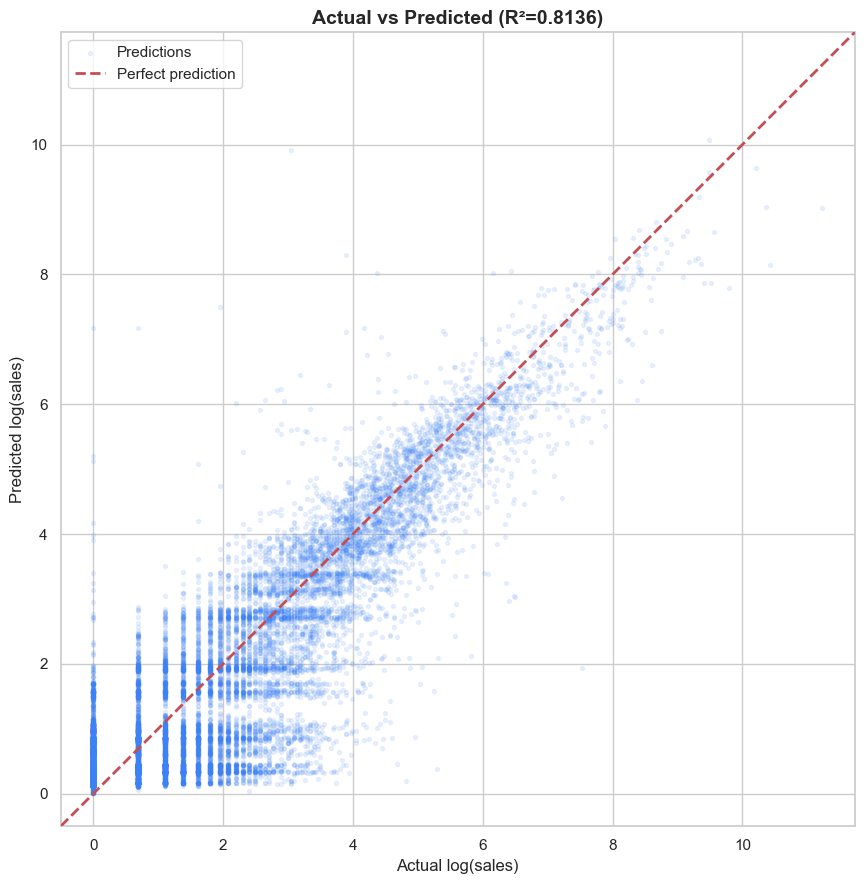

In [5]:
fig, ax = plt.subplots(figsize=(9, 9))
ax.scatter(y_test, y_pred, alpha=0.1, s=8, c='#3b82f6', label='Predictions')

# Perfect prediction line
lims = [min(y_test.min(), y_pred.min())-0.5, max(y_test.max(), y_pred.max())+0.5]
ax.plot(lims, lims, 'r--', lw=2, label='Perfect prediction', zorder=5)

ax.set_xlabel('Actual log(sales)', fontsize=12)
ax.set_ylabel('Predicted log(sales)', fontsize=12)
ax.set_title(f'Actual vs Predicted (R²={r2:.4f})', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()


---
## 4. Residuals Analysis


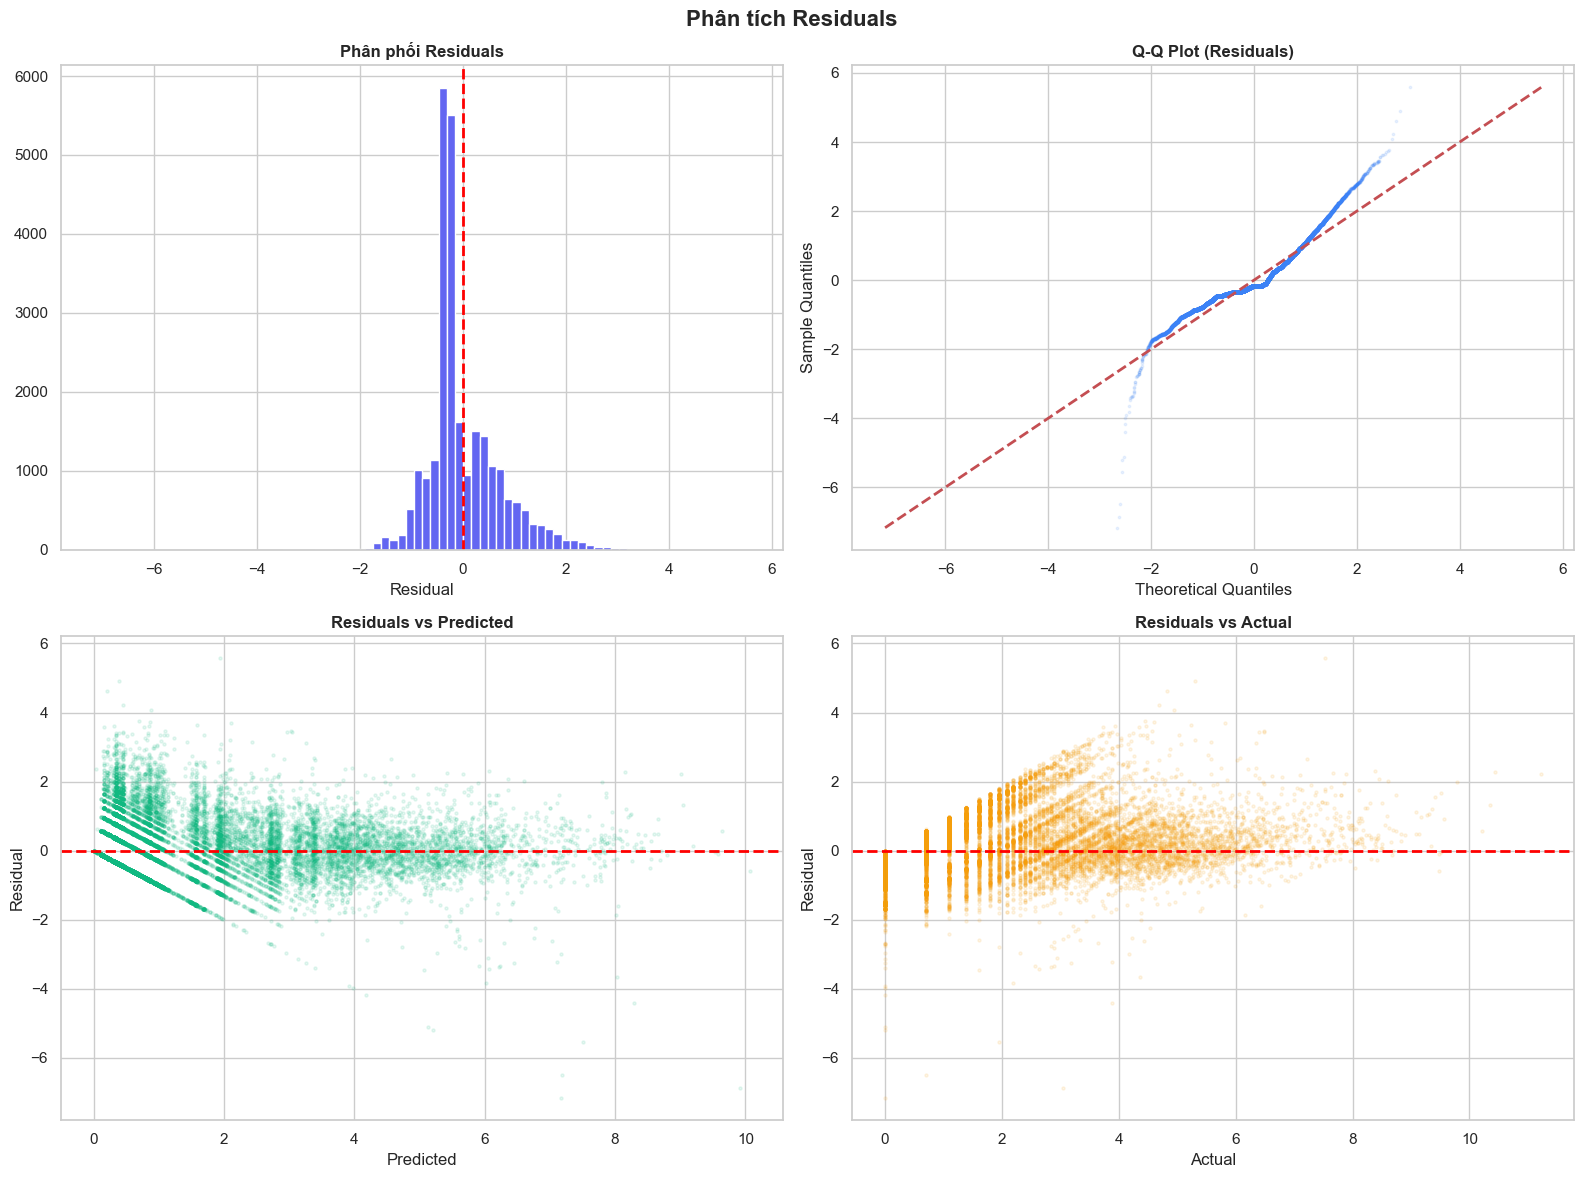

Residuals - mean: -0.0028, std: 0.7342
Residuals - skew: 0.8721


In [6]:
residuals = y_test - y_pred

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Histogram
axes[0,0].hist(residuals, bins=80, color='#6366f1', edgecolor='white')
axes[0,0].axvline(0, color='red', linestyle='--', lw=2)
axes[0,0].set_title('Phân phối Residuals', fontweight='bold')
axes[0,0].set_xlabel('Residual')

# QQ plot (manual)
sorted_res = np.sort(residuals)
n = len(sorted_res)
theoretical = np.sort(np.random.normal(0, residuals.std(), n))
axes[0,1].scatter(theoretical, sorted_res, alpha=0.1, s=3, c='#3b82f6')
qq_lims = [min(theoretical.min(), sorted_res.min()), max(theoretical.max(), sorted_res.max())]
axes[0,1].plot(qq_lims, qq_lims, 'r--', lw=2)
axes[0,1].set_title('Q-Q Plot (Residuals)', fontweight='bold')
axes[0,1].set_xlabel('Theoretical Quantiles')
axes[0,1].set_ylabel('Sample Quantiles')

# Residuals vs Predicted
axes[1,0].scatter(y_pred, residuals, alpha=0.1, s=5, c='#10b981')
axes[1,0].axhline(0, color='red', linestyle='--', lw=2)
axes[1,0].set_title('Residuals vs Predicted', fontweight='bold')
axes[1,0].set_xlabel('Predicted')
axes[1,0].set_ylabel('Residual')

# Residuals vs Actual
axes[1,1].scatter(y_test, residuals, alpha=0.1, s=5, c='#f59e0b')
axes[1,1].axhline(0, color='red', linestyle='--', lw=2)
axes[1,1].set_title('Residuals vs Actual', fontweight='bold')
axes[1,1].set_xlabel('Actual')
axes[1,1].set_ylabel('Residual')

plt.suptitle('Phân tích Residuals', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Residuals - mean: {residuals.mean():.4f}, std: {residuals.std():.4f}")
print(f"Residuals - skew: {residuals.skew():.4f}")


---
## 5. Feature Importance (Chi tiết)


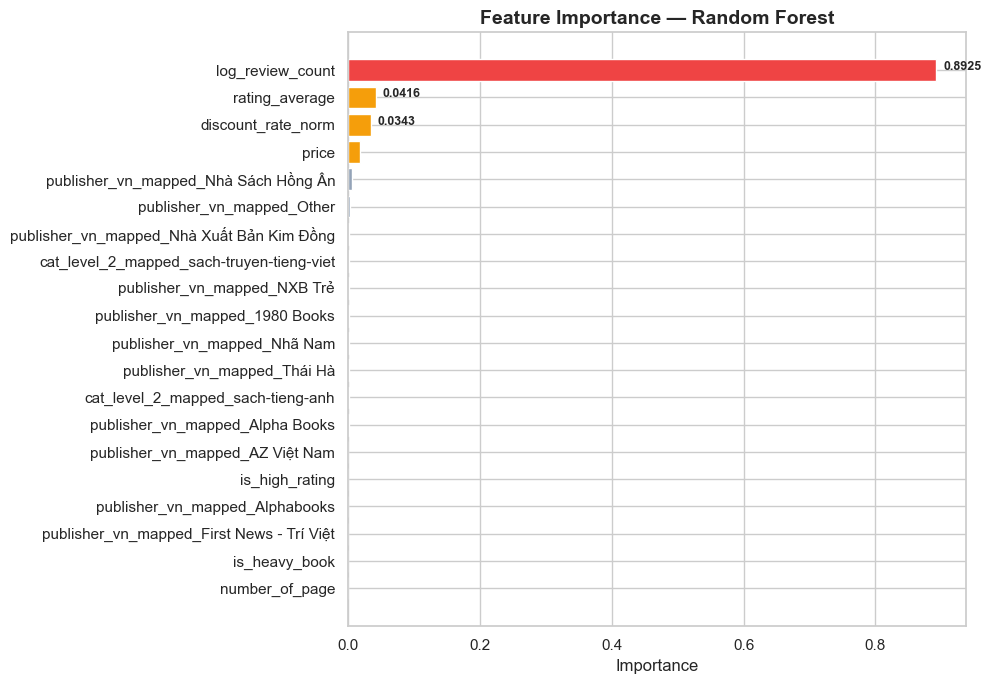


🔥 Top 5 Features:
  1. log_review_count                          89.3%
  2. rating_average                             4.2%
  3. discount_rate_norm                         3.4%
  4. price                                      1.7%
  5. publisher_vn_mapped_Nhà Sách Hồng Ân       0.5%


In [7]:
importances = rf_model.feature_importances_
feat_imp = pd.DataFrame({'feature': ml_features, 'importance': importances}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, max(6, len(feat_imp)*0.35)))
colors = ['#ef4444' if imp > 0.1 else '#f59e0b' if imp > 0.01 else '#94a3b8' for imp in feat_imp['importance']]
ax.barh(feat_imp['feature'], feat_imp['importance'], color=colors, edgecolor='white')
ax.set_xlabel('Importance', fontsize=12)
ax.set_title('Feature Importance — Random Forest', fontsize=14, fontweight='bold')

# Annotate top 3
for _, row in feat_imp.tail(3).iterrows():
    ax.annotate(f"{row['importance']:.4f}", (row['importance'], row['feature']),
               textcoords="offset points", xytext=(5, 0), fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n🔥 Top 5 Features:")
for i, (_, row) in enumerate(feat_imp.tail(5)[::-1].iterrows(), 1):
    pct = row['importance'] * 100
    print(f"  {i}. {row['feature']:40s} {pct:5.1f}%")


---
## 6. Cluster Evaluation


In [8]:
df_eda = pd.read_csv("../../data/processed/data_eda.csv", low_memory=False)

# Predict clusters
cluster_features = ['rating_average', 'price', 'review_count']
df_eda['log_sales_cl'] = np.log1p(df_eda['all_time_quantity_sold'].fillna(0))
cluster_cols = ['log_sales_cl'] + cluster_features
X_cl = df_eda[cluster_cols].fillna(0)

df_eda['cluster'] = kmeans.predict(cluster_scaler.transform(X_cl))

print("Cluster Distribution:")
print(df_eda['cluster'].value_counts().sort_index())


Cluster Distribution:
cluster
0     2819
1    30942
2       78
3    99116
Name: count, dtype: int64


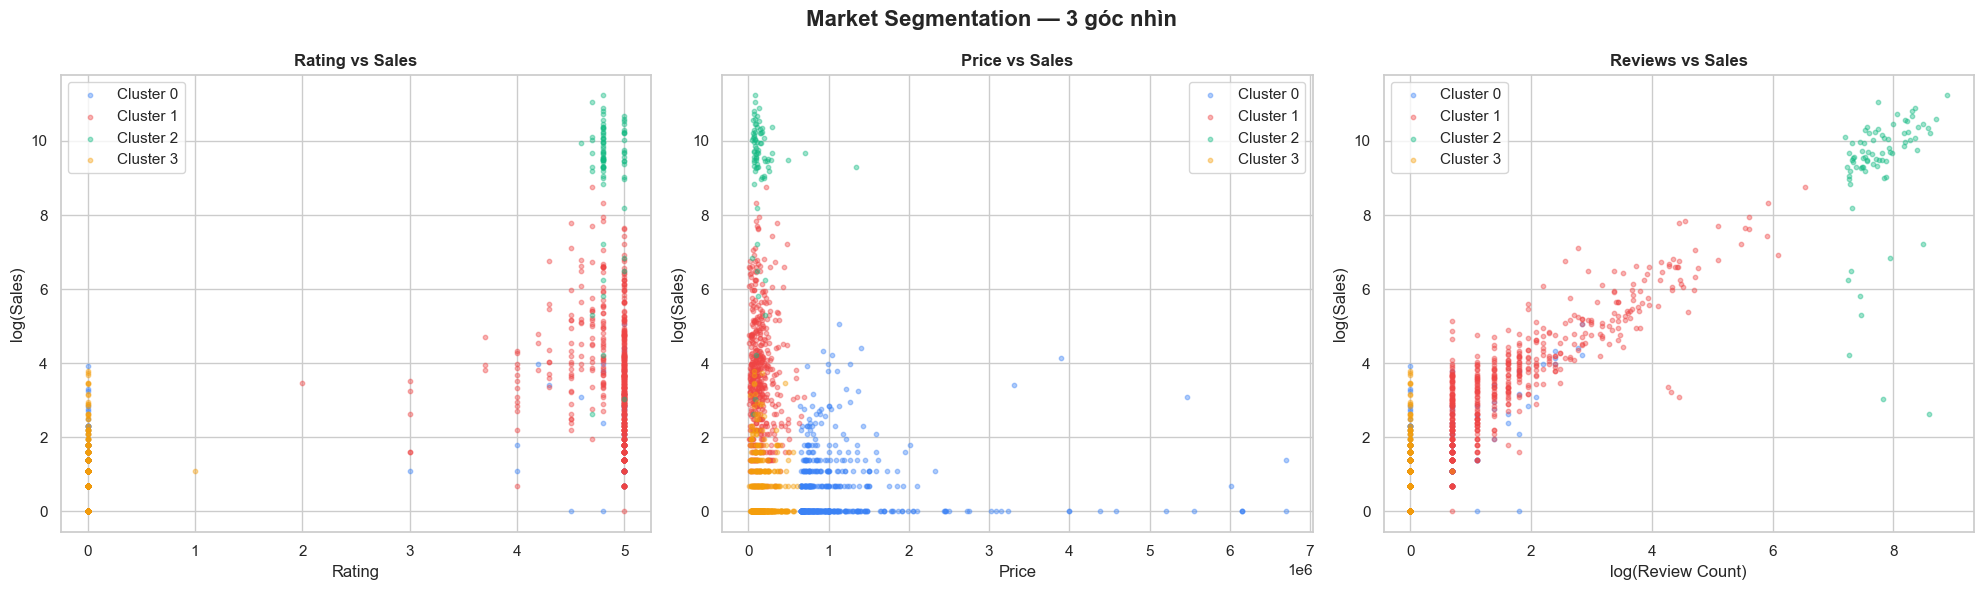

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
colors = ['#3b82f6', '#ef4444', '#10b981', '#f59e0b']

# Rating vs Sales
for c in sorted(df_eda['cluster'].unique()):
    sub = df_eda[df_eda['cluster']==c].sample(min(500, (df_eda['cluster']==c).sum()), random_state=42)
    axes[0].scatter(sub['rating_average'], sub['log_sales_cl'], alpha=0.4, s=10, c=colors[c], label=f'Cluster {c}')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('log(Sales)')
axes[0].set_title('Rating vs Sales', fontweight='bold')
axes[0].legend()

# Price vs Sales
for c in sorted(df_eda['cluster'].unique()):
    sub = df_eda[df_eda['cluster']==c].sample(min(500, (df_eda['cluster']==c).sum()), random_state=42)
    axes[1].scatter(sub['price'], sub['log_sales_cl'], alpha=0.4, s=10, c=colors[c], label=f'Cluster {c}')
axes[1].set_xlabel('Price')
axes[1].set_ylabel('log(Sales)')
axes[1].set_title('Price vs Sales', fontweight='bold')
axes[1].legend()

# Review vs Sales
for c in sorted(df_eda['cluster'].unique()):
    sub = df_eda[df_eda['cluster']==c].sample(min(500, (df_eda['cluster']==c).sum()), random_state=42)
    axes[2].scatter(np.log1p(sub['review_count']), sub['log_sales_cl'], alpha=0.4, s=10, c=colors[c], label=f'Cluster {c}')
axes[2].set_xlabel('log(Review Count)')
axes[2].set_ylabel('log(Sales)')
axes[2].set_title('Reviews vs Sales', fontweight='bold')
axes[2].legend()

plt.suptitle('Market Segmentation — 3 góc nhìn', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


In [10]:
print("=" * 60)
print("        CLUSTER PROFILING")
print("=" * 60)
cluster_profile = df_eda.groupby('cluster').agg(
    count=('cluster', 'size'),
    avg_sales=('all_time_quantity_sold', 'mean'),
    med_sales=('all_time_quantity_sold', 'median'),
    avg_rating=('rating_average', 'mean'),
    avg_price=('price', 'mean'),
    avg_reviews=('review_count', 'mean'),
).round(2)

for c in cluster_profile.index:
    row = cluster_profile.loc[c]
    print(f"\nCluster {c} ({int(row['count'])} items):")
    print(f"  Avg Sales:   {row['avg_sales']:>10.1f}")
    print(f"  Med Sales:   {row['med_sales']:>10.1f}")
    print(f"  Avg Rating:  {row['avg_rating']:>10.2f}")
    print(f"  Avg Price:   {row['avg_price']:>10.0f}")
    print(f"  Avg Reviews: {row['avg_reviews']:>10.1f}")


        CLUSTER PROFILING

Cluster 0 (2819 items):
  Avg Sales:          4.9
  Med Sales:          0.0
  Avg Rating:        0.56
  Avg Price:      1126581
  Avg Reviews:        0.8

Cluster 1 (30942 items):
  Avg Sales:        177.0
  Med Sales:         32.0
  Avg Rating:        4.83
  Avg Price:       145369
  Avg Reviews:       19.5

Cluster 2 (78 items):
  Avg Sales:      19642.8
  Med Sales:      15959.0
  Avg Rating:        4.84
  Avg Price:       149656
  Avg Reviews:     2648.7

Cluster 3 (99116 items):
  Avg Sales:          1.7
  Med Sales:          0.0
  Avg Rating:        0.01
  Avg Price:       164397
  Avg Reviews:        0.0


---
## 7. Kết luận

### Random Forest Regressor:
- **R² ≈ 0.82**: Model giải thích tốt 82% phương sai log(sales)
- **RMSE ≈ 0.73**: Sai số khá nhỏ trên thang log
- **Feature quan trọng nhất**: `log_review_count` (hiệu ứng đám đông)
- Residuals phân phối gần chuẩn, không có bias hệ thống

### KMeans Clustering:
- 4 phân khúc rõ ràng: Best Seller / Normal / Niche / Low Performer
- Giúp seller xác định chiến lược phù hợp cho từng nhóm sách

